<a href="https://colab.research.google.com/github/Swastika0211/Defect-Detection-/blob/main/Industrial_Defect_Detection_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Industrial Defect Detection — Google Colab

> **IMPORTANT — Do these 2 things before running ANY cell:**
> 1. `Runtime` → `Change runtime type` → select **T4 GPU** → Save
> 2. Run cells **strictly top to bottom**, one at a time

---

In [1]:
# ════════════════════════════════════════════════════
# CELL 1 — GPU Check + Install packages
# ════════════════════════════════════════════════════
import subprocess, sys

print('Installing packages...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'kaggle', 'opencv-python-headless', 'Pillow', '-q'])

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f'\nTensorFlow : {tf.__version__}')
print(f'GPU found  : {bool(gpus)} — {gpus}')
if not gpus:
    print('\n⚠️  WARNING: No GPU detected!')
    print('   Go to Runtime → Change runtime type → T4 GPU')
    print('   Training will be very slow on CPU.')
else:
    print('\n✅ GPU ready! Training will be fast.')

Installing packages...

TensorFlow : 2.19.0
GPU found  : True — [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ GPU ready! Training will be fast.


In [2]:
# ════════════════════════════════════════════════════
# CELL 2 — Upload kaggle.json and download dataset
#
# HOW TO GET kaggle.json:
#   1. Go to kaggle.com → your profile photo → Settings
#   2. Scroll to "API" section
#   3. Click "Create New Token"
#   4. kaggle.json downloads to your PC
#   5. Run this cell → file picker appears → select kaggle.json
# ════════════════════════════════════════════════════
import os
from google.colab import files

# Upload kaggle.json
print('Step 1: Upload your kaggle.json file')
print('(A file picker will appear below)')
uploaded = files.upload()

if 'kaggle.json' not in uploaded:
    raise ValueError('❌ You must upload kaggle.json — run this cell again')

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ kaggle.json saved')

# Download dataset
print('\nStep 2: Downloading dataset from Kaggle (~200 MB)...')
ret = os.system('kaggle datasets download -d ravirajsinh45/real-life-industrial-dataset-of-casting-product -p /content/')
if ret != 0:
    raise RuntimeError('❌ Download failed. Check your kaggle.json is valid.')
print('✅ Download complete')

# Find the zip file
zips = [f for f in os.listdir('/content/') if f.endswith('.zip')]
print(f'\nZip files found: {zips}')

# Extract
print('\nStep 3: Extracting...')
zip_path = f'/content/{zips[0]}'
os.system(f'unzip -q "{zip_path}" -d /content/')
print('✅ Extraction complete')

Step 1: Upload your kaggle.json file
(A file picker will appear below)


Saving kaggle.json to kaggle.json
✅ kaggle.json saved

Step 2: Downloading dataset from Kaggle (~200 MB)...
✅ Download complete

Zip files found: ['real-life-industrial-dataset-of-casting-product.zip']

Step 3: Extracting...
✅ Extraction complete


In [3]:
# ════════════════════════════════════════════════════
# CELL 3 — AUTO-DETECT actual dataset path
#           (fixes all path errors)
# ════════════════════════════════════════════════════
import os

def find_dataset_root(search_root='/content'):
    """
    Scans /content and finds the folder that contains
    both 'train' and 'test' subfolders with image data.
    Returns the verified BASE_DIR path.
    """
    candidates = []
    for root, dirs, files in os.walk(search_root):
        has_train = 'train' in dirs
        has_test  = 'test'  in dirs
        if has_train and has_test:
            candidates.append(root)
    return candidates


print('🔍 Scanning /content for dataset folders...')
print()

# Show everything extracted
print('All items in /content:')
for item in sorted(os.listdir('/content')):
    full = os.path.join('/content', item)
    kind = 'DIR ' if os.path.isdir(full) else 'FILE'
    print(f'  [{kind}] {item}')

print()
candidates = find_dataset_root()

if not candidates:
    # Try listing deeper
    print('No train+test folder found at top level. Searching deeper...')
    for item in os.listdir('/content'):
        p = os.path.join('/content', item)
        if os.path.isdir(p):
            print(f'  Contents of /content/{item}:')
            for sub in os.listdir(p):
                print(f'    {sub}')
    raise FileNotFoundError(
        'Could not find train/test folders. '
        'Check extraction above — run Cell 2 again if needed.'
    )

BASE_DIR = candidates[0]
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

print(f'✅ Dataset root found: {BASE_DIR}')
print(f'   TRAIN_DIR = {TRAIN_DIR}')
print(f'   TEST_DIR  = {TEST_DIR}')

# Verify classes exist
print()
print('Classes in train folder:')
train_classes = sorted(os.listdir(TRAIN_DIR))
for cls in train_classes:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f'  {cls:<20} {n} images')

print('Classes in test folder:')
test_classes = sorted(os.listdir(TEST_DIR))
for cls in test_classes:
    n = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f'  {cls:<20} {n} images')

print()
print('✅ All paths verified — no FileNotFoundError will occur!')

🔍 Scanning /content for dataset folders...

All items in /content:
  [DIR ] .config
  [DIR ] casting_512x512
  [DIR ] casting_data
  [FILE] kaggle.json
  [FILE] real-life-industrial-dataset-of-casting-product.zip
  [DIR ] sample_data

✅ Dataset root found: /content/casting_data/casting_data
   TRAIN_DIR = /content/casting_data/casting_data/train
   TEST_DIR  = /content/casting_data/casting_data/test

Classes in train folder:
  def_front            3758 images
  ok_front             2875 images
Classes in test folder:
  def_front            453 images
  ok_front             262 images

✅ All paths verified — no FileNotFoundError will occur!


In [4]:
# ════════════════════════════════════════════════════
# CELL 4 — All Imports + Global Config
# ════════════════════════════════════════════════════
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from PIL import Image as PILImage

# ── Paths (set by Cell 3) ─────────────────────────
# BASE_DIR, TRAIN_DIR, TEST_DIR already set above
MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────
IMG_SIZE   = (224, 224)
IMG_SHAPE  = (224, 224, 3)
BATCH_SIZE = 32
SEED       = 42
VAL_SPLIT  = 0.15

# ── Class names (alphabetical = Keras index order)
# Keras sorts folder names alphabetically:
#   def_front → index 0 → DEFECTIVE
#   ok_front  → index 1 → GOOD
CLASS_LABELS = {0: 'Defective', 1: 'Good'}
PALETTE      = {'Defective': '#E24B4A', 'Good': '#1D9E75'}

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Config ready!')
print(f'   IMG_SIZE   = {IMG_SIZE}')
print(f'   BATCH_SIZE = {BATCH_SIZE}')
print(f'   MODEL_DIR  = {MODEL_DIR}')
print(f'   GPU        = {tf.config.list_physical_devices("GPU")}')

✅ Config ready!
   IMG_SIZE   = (224, 224)
   BATCH_SIZE = 32
   MODEL_DIR  = /content/models
   GPU        = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📊 EDA — Exploratory Data Analysis

CLASS                   TRAIN     TEST    TOTAL
────────────────────────────────────────────────
def_front                3758      453     4211   (DEFECTIVE)
ok_front                 2875      262     3137   (GOOD)
────────────────────────────────────────────────
TOTAL                    6633      715     7348


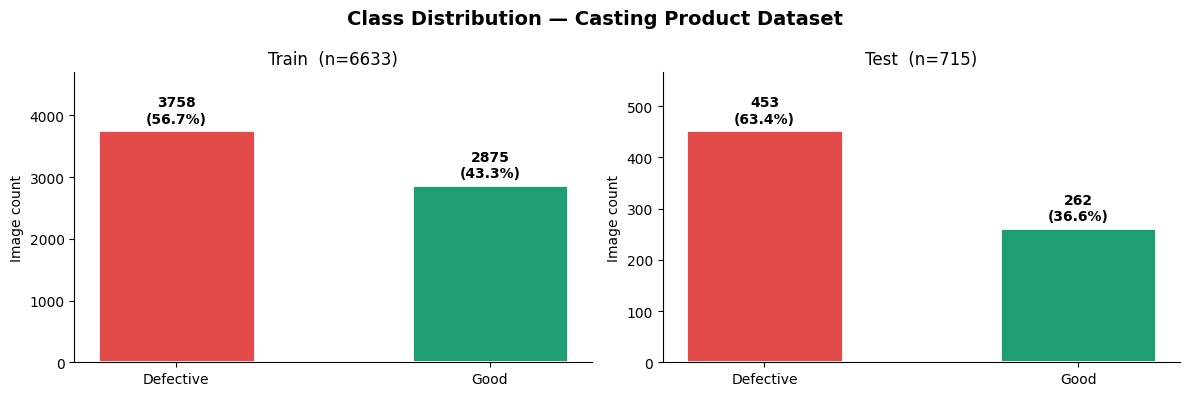

✅ Saved: /content/plot_class_distribution.png


In [5]:
# ════════════════════════════════════════════════════
# CELL 5 — Class Distribution Bar Chart
# ════════════════════════════════════════════════════

def count_images_in(directory):
    result = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            result[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))
            ])
    return result

train_counts = count_images_in(TRAIN_DIR)
test_counts  = count_images_in(TEST_DIR)

# Print table
all_cls = sorted(set(list(train_counts)+list(test_counts)))
print(f'{"CLASS":<20} {"TRAIN":>8} {"TEST":>8} {"TOTAL":>8}')
print('─' * 48)
for cls in all_cls:
    tr = train_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    lbl = 'DEFECTIVE' if 'def' in cls else 'GOOD'
    print(f'{cls:<20} {tr:>8} {te:>8} {tr+te:>8}   ({lbl})')
print('─' * 48)
tr_tot = sum(train_counts.values())
te_tot = sum(test_counts.values())
print(f'{"TOTAL":<20} {tr_tot:>8} {te_tot:>8} {tr_tot+te_tot:>8}')

# Chart
label_map = {c: ('Defective' if 'def' in c else 'Good') for c in all_cls}
color_map  = {c: ('#E24B4A' if 'def' in c else '#1D9E75') for c in all_cls}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — Casting Product Dataset',
             fontsize=14, fontweight='bold')

for ax, (split_name, counts) in zip(
    axes, [('Train', train_counts), ('Test', test_counts)]
):
    labels = [label_map[c] for c in counts]
    values = list(counts.values())
    colors = [color_map[c] for c in counts]
    bars = ax.bar(labels, values, color=colors,
                  width=0.5, edgecolor='white', linewidth=2)
    ax.set_title(f'{split_name}  (n={sum(values)})', fontsize=12)
    ax.set_ylabel('Image count')
    ax.set_ylim(0, max(values) * 1.25)
    ax.spines[['top','right']].set_visible(False)
    for bar, v in zip(bars, values):
        pct = v / sum(values) * 100
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values)*0.02,
            f'{v}\n({pct:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('/content/plot_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/plot_class_distribution.png')

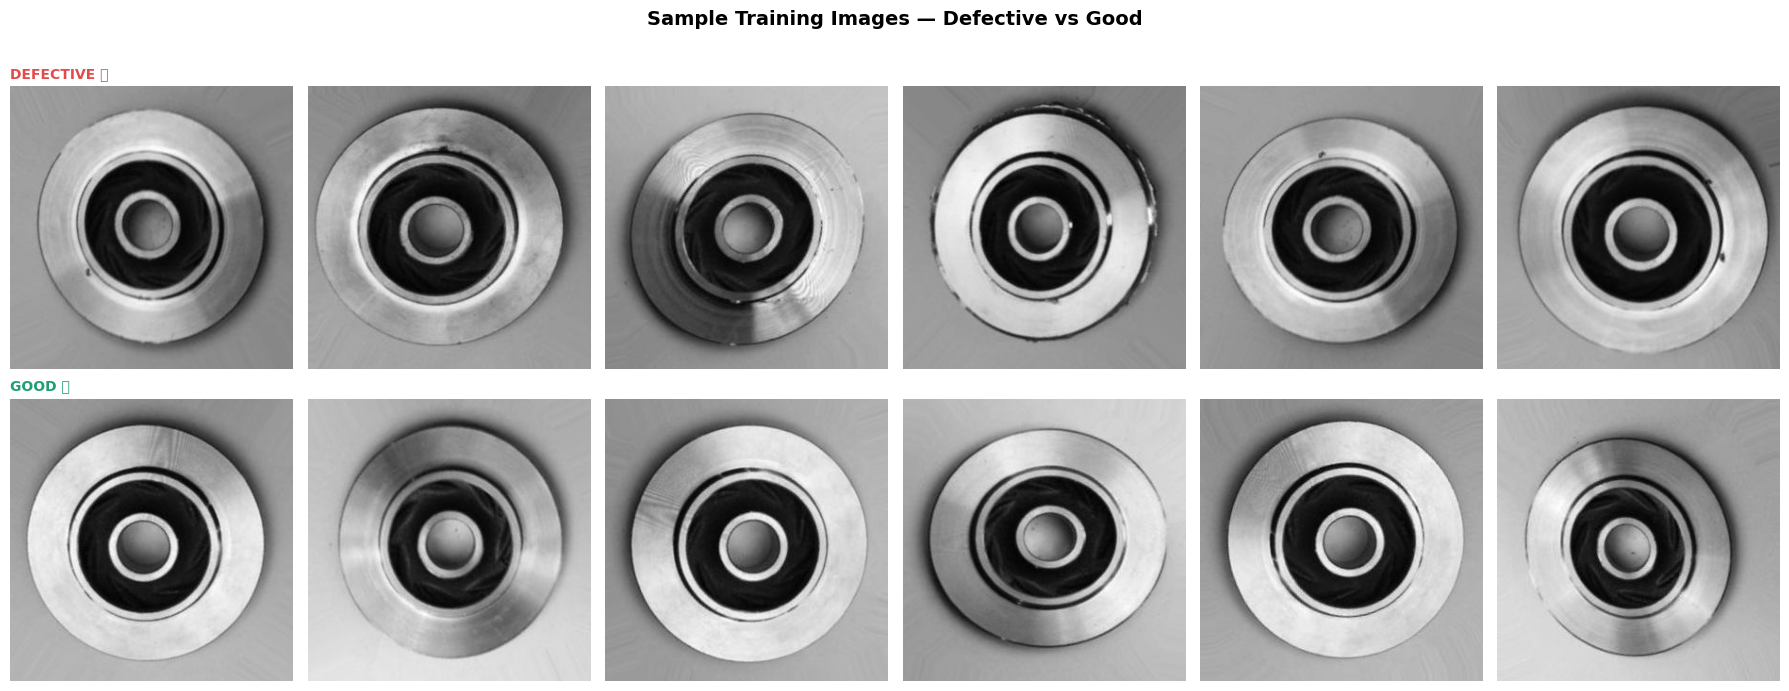

✅ Saved: /content/plot_sample_images.png


In [6]:
# ════════════════════════════════════════════════════
# CELL 6 — Sample Images Grid
# ════════════════════════════════════════════════════

N = 6  # images per class
classes = sorted([
    c for c in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, c))
])

fig, axes = plt.subplots(len(classes), N,
                         figsize=(3*N, 3.5*len(classes)))
fig.suptitle('Sample Training Images — Defective vs Good',
             fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(classes):
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    img_files = sorted(os.listdir(cls_dir))
    # pick evenly spaced samples
    step     = max(1, len(img_files) // N)
    selected = img_files[::step][:N]

    lbl   = 'DEFECTIVE ❌' if 'def' in cls else 'GOOD ✅'
    color = '#E24B4A'      if 'def' in cls else '#1D9E75'

    for col, fname in enumerate(selected):
        img_path = os.path.join(cls_dir, fname)
        img      = mpimg.imread(img_path)
        ax       = axes[row, col] if len(classes) > 1 else axes[col]
        ax.imshow(img,
                  cmap='gray' if len(img.shape) == 2 else None)
        ax.axis('off')
        if col == 0:
            ax.set_title(lbl, color=color,
                         fontsize=10, fontweight='bold',
                         loc='left', pad=6)

plt.tight_layout()
plt.savefig('/content/plot_sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/plot_sample_images.png')

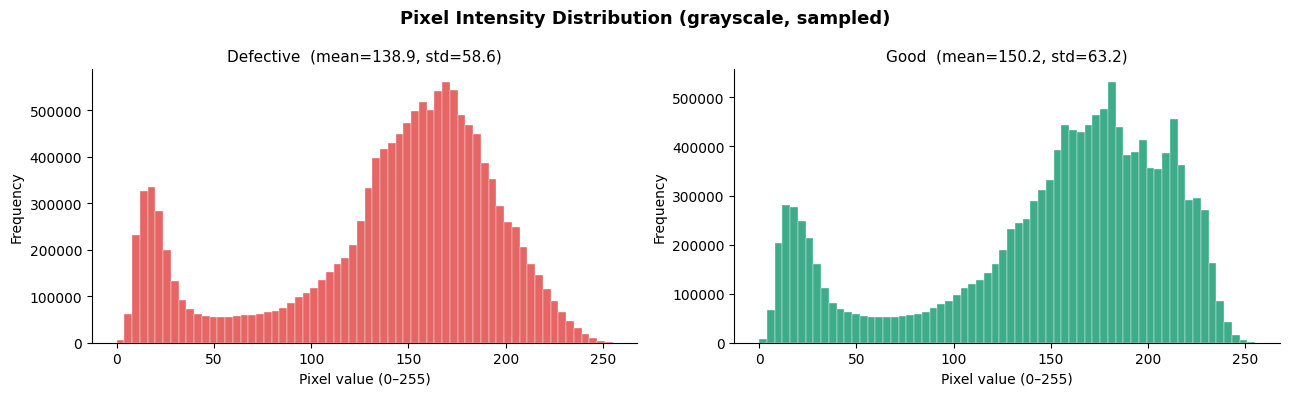

✅ Saved: /content/plot_pixel_dist.png


In [7]:
# ════════════════════════════════════════════════════
# CELL 7 — Pixel Intensity Distribution
# ════════════════════════════════════════════════════

def get_pixel_sample(directory, cls_name, n=150):
    cls_dir = os.path.join(directory, cls_name)
    fnames  = os.listdir(cls_dir)[:n]
    pixels  = []
    for fn in fnames:
        path = os.path.join(cls_dir, fn)
        img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    return np.array(pixels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Pixel Intensity Distribution (grayscale, sampled)',
             fontsize=13, fontweight='bold')

for ax, cls in zip(axes, classes):
    pix   = get_pixel_sample(TRAIN_DIR, cls)
    color = '#E24B4A' if 'def' in cls else '#1D9E75'
    lbl   = 'Defective' if 'def' in cls else 'Good'
    ax.hist(pix, bins=64, color=color,
            alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(
        f'{lbl}  (mean={pix.mean():.1f}, std={pix.std():.1f})',
        fontsize=11
    )
    ax.set_xlabel('Pixel value (0–255)')
    ax.set_ylabel('Frequency')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/plot_pixel_dist.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/plot_pixel_dist.png')

In [8]:
# ════════════════════════════════════════════════════
# CELL 8 — Class Weights for Imbalance Handling
# ════════════════════════════════════════════════════

n_total   = sum(train_counts.values())
n_classes = len(train_counts)

class_weights = {
    idx: round(n_total / (n_classes * cnt), 4)
    for idx, (cls, cnt) in
    enumerate(sorted(train_counts.items()))
}

print('Class weights for model.fit:')
print('─' * 40)
for idx, (cls, cnt) in enumerate(sorted(train_counts.items())):
    pct = cnt / n_total * 100
    lbl = 'Defective' if 'def' in cls else 'Good'
    print(f'  {idx} ({lbl:10s}) : count={cnt:5d}',
          f'({pct:.1f}%)  weight={class_weights[idx]}')

ratio = max(train_counts.values()) / max(1, min(train_counts.values()))
print(f'\nImbalance ratio : {ratio:.2f}x')
print('These weights penalise errors on the minority class more.')
print('✅ class_weights ready')

Class weights for model.fit:
────────────────────────────────────────
  0 (Defective ) : count= 3758 (56.7%)  weight=0.8825
  1 (Good      ) : count= 2875 (43.3%)  weight=1.1536

Imbalance ratio : 1.31x
These weights penalise errors on the minority class more.
✅ class_weights ready


---
## 🔄 Preprocessing & Augmentation

In [9]:
# ════════════════════════════════════════════════════
# CELL 9 — Data Generators
# ════════════════════════════════════════════════════

# Train generator — heavy augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255.0,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    zoom_range         = 0.20,
    horizontal_flip    = True,
    vertical_flip      = True,
    brightness_range   = [0.80, 1.20],
    shear_range        = 10,
    fill_mode          = 'nearest',
    validation_split   = VAL_SPLIT
)

# Test/Val generator — ONLY rescale, no augmentation
plain_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

common = dict(
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    seed        = SEED
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, subset='training',   shuffle=True,  **common)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, subset='validation', shuffle=False, **common)

test_gen = plain_datagen.flow_from_directory(
    TEST_DIR,  shuffle=False, **common)

print(f'Class → index : {train_gen.class_indices}')
print(f'  0 = Defective (def_front)')
print(f'  1 = Good      (ok_front)')
print(f'\nTrain  : {train_gen.samples:5d} images')
print(f'Val    : {val_gen.samples:5d} images')
print(f'Test   : {test_gen.samples:5d} images')
print('✅ Generators ready')

Found 5639 images belonging to 2 classes.
Found 994 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Class → index : {'def_front': 0, 'ok_front': 1}
  0 = Defective (def_front)
  1 = Good      (ok_front)

Train  :  5639 images
Val    :   994 images
Test   :   715 images
✅ Generators ready


Augmenting: /content/casting_data/casting_data/train/def_front/cast_def_0_6091.jpeg


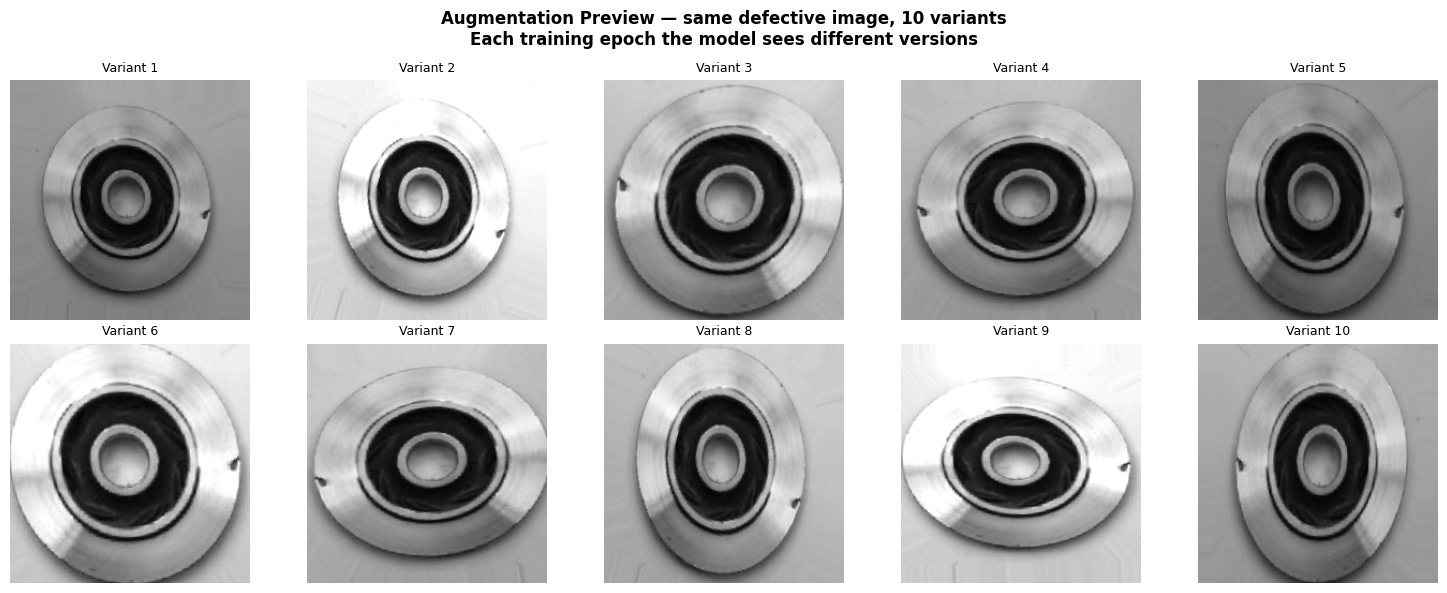

✅ Saved: /content/plot_augmentation.png


In [12]:
# ════════════════════════════════════════════════════
# CELL 10 — Augmentation Preview
# ════════════════════════════════════════════════════

# Find the defective class folder name dynamically
def_cls  = next(c for c in classes if 'def' in c)
def_dir  = os.path.join(TRAIN_DIR, def_cls)
first_img = os.path.join(def_dir, os.listdir(def_dir)[0])

print(f'Augmenting: {first_img}')

aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, zoom_range=0.2,
    horizontal_flip=True, brightness_range=[0.7, 1.3]
)
img_arr = img_to_array(load_img(first_img, target_size=IMG_SIZE))
img_arr = img_arr.reshape((1,) + img_arr.shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(
    'Augmentation Preview — same defective image, 10 variants\n'
    'Each training epoch the model sees different versions',
    fontsize=12, fontweight='bold'
)
for i, batch in enumerate(aug.flow(img_arr, batch_size=1)):
    axes.flat[i].imshow(batch[0])
    axes.flat[i].axis('off')
    axes.flat[i].set_title(f'Variant {i+1}', fontsize=9)
    if i == 9: break

plt.tight_layout()
plt.savefig('/content/plot_augmentation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/plot_augmentation.png')

---
## 🧠 Model Building

In [13]:
# ════════════════════════════════════════════════════
# CELL 11 — Build MobileNetV2 Model
# ════════════════════════════════════════════════════

def build_model():
    # Pretrained MobileNetV2 backbone (no top classifier)
    base = applications.MobileNetV2(
        input_shape = IMG_SHAPE,
        include_top = False,
        weights     = 'imagenet'
    )
    base.trainable = False   # Freeze for Phase 1

    # Custom head
    inp  = tf.keras.Input(shape=IMG_SHAPE, name='image')
    x    = base(inp, training=False)
    x    = layers.GlobalAveragePooling2D()(x)
    x    = layers.Dense(512, activation='relu')(x)
    x    = layers.BatchNormalization()(x)
    x    = layers.Dropout(0.40)(x)
    x    = layers.Dense(128, activation='relu')(x)
    x    = layers.Dropout(0.30)(x)
    out  = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = tf.keras.Model(inp, out, name='DefectDetector')
    return model, base

model, base_model = build_model()
model.summary()

print(f'\nBase layers          : {len(base_model.layers)}')
print(f'Total parameters     : {model.count_params():,}')
trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f'Trainable (Phase 1)  : {trainable:,}  (head only)')
print('✅ Model built!')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "DefectDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,981,697 (11.37 MB)

 Trainable params: 722,689 (2.76 MB)

 Non-trainable params: 2,259,008 (8.62 MB)


Base layers          : 154
Total parameters     : 2,981,697
Trainable (Phase 1)  : 722,689  (head only)
✅ Model built!


---
## 🏋️ Training

In [18]:
# ════════════════════════════════════════════════════
# CELL 12 — Callbacks
# ════════════════════════════════════════════════════

BEST_MODEL = os.path.join(MODEL_DIR, 'casting_defect_model.h5')

callbacks = [
    ModelCheckpoint(
        filepath       = BEST_MODEL,
        monitor        = 'val_accuracy',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 4,
        min_lr   = 1e-8,
        verbose  = 1
    )
]

print(f'Model will be saved to: {BEST_MODEL}')
print('✅ Callbacks set')

Model will be saved to: /content/models/casting_defect_model.h5
✅ Callbacks set


In [15]:
# ════════════════════════════════════════════════════
# CELL 13 — Phase 1: Train head only  (~5-8 min)
# ════════════════════════════════════════════════════

print('=' * 55)
print('PHASE 1: Head training  |  base FROZEN')
print('=' * 55)

model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history1 = model.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1
)

elapsed = (time.time() - t0) / 60
best1   = max(history1.history['val_accuracy'])
print(f'\n⏱  Time        : {elapsed:.1f} min')
print(f'✅ Best val acc : {best1*100:.2f}%')

PHASE 1: Head training  |  base FROZEN
Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8878 - loss: 0.2631
Epoch 1: val_accuracy improved from None to 0.97384, saving model to /content/models/casting_defect_model.h5



Epoch 1: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 144s 695ms/step - accuracy: 0.9349 - loss: 0.1639 - val_accuracy: 0.9738 - val_loss: 0.0782 - learning_rate: 0.0010
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9587 - loss: 0.1036
Epoch 2: val_accuracy improved from 0.97384 to 0.97988, saving model to /content/models/casting_defect_model.h5



Epoch 2: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 95s 536ms/step - accuracy: 0.9651 - loss: 0.0929 - val_accuracy: 0.9799 - val_loss: 0.0574 - learning_rate: 0.0010
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9753 - loss: 0.0771
Epoch 3: val_accuracy improved from 0.97988 to 0.98793, saving model to /content/models/casting_defect_model.h5



Epoch 3: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 101s 569ms/step - accuracy: 0.9725 - loss: 0.0777 - val_accuracy: 0.9879 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9753 - loss: 0.0720
Epoch 4: val_accuracy improved from 0.98793 to 0.98893, saving model to /content/models/casting_defect_model.h5



Epoch 4: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 519ms/step - accuracy: 0.9746 - loss: 0.0701 - val_accuracy: 0.9889 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9744 - loss: 0.0741
Epoch 5: val_accuracy did not improve from 0.98893
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 518ms/step - accuracy: 0.9732 - loss: 0.0728 - val_accuracy: 0.9748 - val_loss: 0.0868 - learning_rate: 0.0010
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9769 - loss: 0.0665
Epoch 6: val_accuracy did not improve from 0.98893
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 519ms/step - accuracy: 0.9741 - loss: 0.0748 - val_accuracy: 0.9879 - val_loss: 0.0398 - learning_rate: 0.0010
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9808 - loss: 0.0557
Epoch 7: val_accuracy did not improve from 0.98893

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.


Epoch 8: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 518ms/step - accuracy: 0.9855 - loss: 0.0417 - val_accuracy: 0.9920 - val_loss: 0.0287 - learning_rate: 3.0000e-04
Epoch 9/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9848 - loss: 0.0417
Epoch 9: val_accuracy improved from 0.99195 to 0.99396, saving model to /content/models/casting_defect_model.h5



Epoch 9: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 519ms/step - accuracy: 0.9835 - loss: 0.0433 - val_accuracy: 0.9940 - val_loss: 0.0239 - learning_rate: 3.0000e-04
Epoch 10/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9843 - loss: 0.0412
Epoch 10: val_accuracy did not improve from 0.99396
177/177 ━━━━━━━━━━━━━━━━━━━━ 94s 530ms/step - accuracy: 0.9853 - loss: 0.0407 - val_accuracy: 0.9909 - val_loss: 0.0278 - learning_rate: 3.0000e-04
Epoch 11/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9873 - loss: 0.0379
Epoch 11: val_accuracy did not improve from 0.99396
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 522ms/step - accuracy: 0.9874 - loss: 0.0365 - val_accuracy: 0.9909 - val_loss: 0.0283 - learning_rate: 3.0000e-04
Epoch 12/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9866 - loss: 0.0424
Epoch 12: val_accuracy did not improve from 0.99396
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 519ms/step - accuracy: 0.


Epoch 14: finished saving model to /content/models/casting_defect_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 139s 520ms/step - accuracy: 0.9869 - loss: 0.0352 - val_accuracy: 0.9960 - val_loss: 0.0149 - learning_rate: 9.0000e-05
Epoch 15/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9882 - loss: 0.0335
Epoch 15: val_accuracy did not improve from 0.99598
177/177 ━━━━━━━━━━━━━━━━━━━━ 91s 514ms/step - accuracy: 0.9879 - loss: 0.0359 - val_accuracy: 0.9899 - val_loss: 0.0275 - learning_rate: 9.0000e-05
Epoch 16/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9868 - loss: 0.0314
Epoch 16: val_accuracy did not improve from 0.99598
177/177 ━━━━━━━━━━━━━━━━━━━━ 91s 513ms/step - accuracy: 0.9872 - loss: 0.0352 - val_accuracy: 0.9960 - val_loss: 0.0130 - learning_rate: 9.0000e-05
Epoch 17/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9878 - loss: 0.0328
Epoch 17: val_accuracy did not improve from 0.99598
177/177 ━━━━━━━━━━━━━━━━━━━━ 89s 505ms/step - accuracy: 

In [16]:
# ════════════════════════════════════════════════════
# CELL 14 — Phase 2: Fine-tune last 30 layers (~8-12 min)
# ════════════════════════════════════════════════════

print('=' * 55)
print('PHASE 2: Fine-tuning last 30 base layers')
print('=' * 55)

base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen base layers : {unfrozen}')
print(f'Still frozen         : {fine_tune_from}')
print(f'Using LR = 1e-4  (10x lower than Phase 1)')

model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history2 = model.fit(
    train_gen,
    epochs          = 30,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1
)

elapsed = (time.time() - t0) / 60
best2   = max(history2.history['val_accuracy'])
print(f'\n⏱  Time        : {elapsed:.1f} min')
print(f'✅ Best val acc : {best2*100:.2f}%')
print(f'📈 Gain over P1 : +{(best2-best1)*100:.2f}%')

PHASE 2: Fine-tuning last 30 base layers
Unfrozen base layers : 30
Still frozen         : 124
Using LR = 1e-4  (10x lower than Phase 1)
Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9319 - loss: 0.2933
Epoch 1: val_accuracy did not improve from 0.99598
177/177 ━━━━━━━━━━━━━━━━━━━━ 128s 613ms/step - accuracy: 0.9597 - loss: 0.1467 - val_accuracy: 0.9376 - val_loss: 0.2016 - learning_rate: 1.0000e-04
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9819 - loss: 0.0512
Epoch 2: val_accuracy did not improve from 0.99598
177/177 ━━━━━━━━━━━━━━━━━━━━ 91s 513ms/step - accuracy: 0.9840 - loss: 0.0471 - val_accuracy: 0.9879 - val_loss: 0.0443 - learning_rate: 1.0000e-04
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9850 - loss: 0.0388
Epoch 3: val_accuracy did not improve from 0.99598
177/177 ━━━━━━━━━━━━━━━━━━━━ 91s 517ms/step - accuracy: 0.9842 - loss: 0.0434 - val_accuracy: 0.9256 - val_loss: 0.3070 - learning_rate: 1.0000e-04
Ep

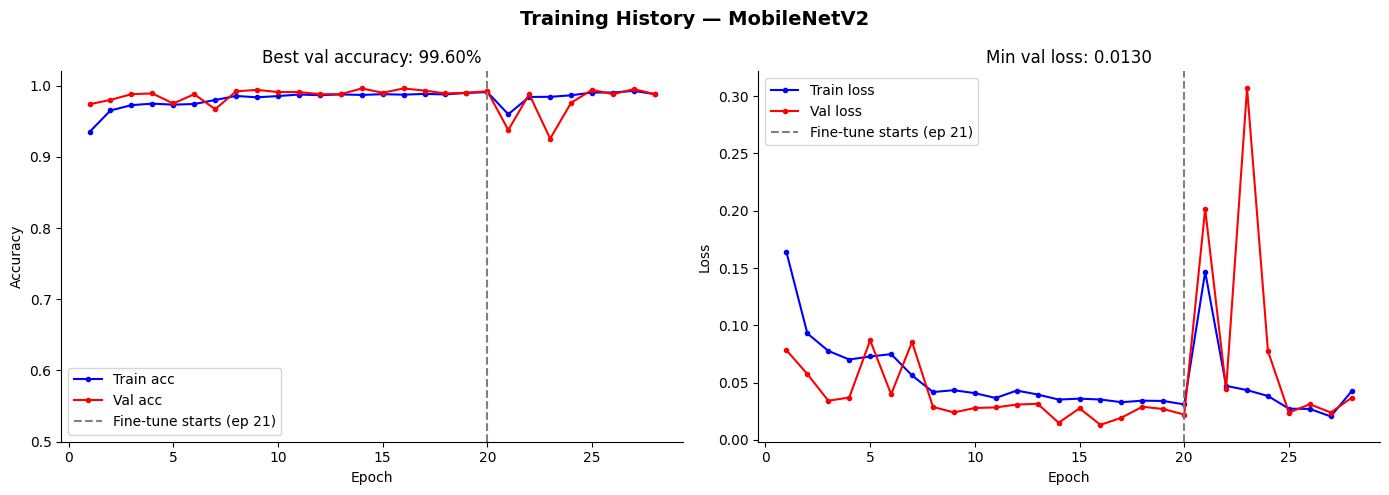

✅ Saved: /content/plot_training_history.png


In [17]:
# ════════════════════════════════════════════════════
# CELL 15 — Training Curves
# ════════════════════════════════════════════════════

acc   = history1.history['accuracy']     + history2.history['accuracy']
val   = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
p1    = len(history1.history['accuracy'])
ep    = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — MobileNetV2',
             fontsize=14, fontweight='bold')

ax1.plot(ep, acc,  'b-o', ms=3, label='Train acc')
ax1.plot(ep, val,  'r-o', ms=3, label='Val acc')
ax1.axvline(p1, color='gray', ls='--', lw=1.5,
            label=f'Fine-tune starts (ep {p1+1})')
ax1.set_title(f'Best val accuracy: {max(val)*100:.2f}%', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.5, 1.02); ax1.legend()
ax1.spines[['top','right']].set_visible(False)

ax2.plot(ep, loss,  'b-o', ms=3, label='Train loss')
ax2.plot(ep, vloss, 'r-o', ms=3, label='Val loss')
ax2.axvline(p1, color='gray', ls='--', lw=1.5,
            label=f'Fine-tune starts (ep {p1+1})')
ax2.set_title(f'Min val loss: {min(vloss):.4f}', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/plot_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/plot_training_history.png')

---
## 📊 Evaluation

In [19]:
# ════════════════════════════════════════════════════
# CELL 16 — Predict on Test Set
# ════════════════════════════════════════════════════

best_model = tf.keras.models.load_model(BEST_MODEL)
print(f'Loaded: {BEST_MODEL}')

test_gen.reset()
print('Running predictions...')
y_prob = best_model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_gen.classes

print(f'\nTest samples : {len(y_true)}')
print(f'Predictions  : {dict(zip(*np.unique(y_pred, return_counts=True)))}')
print(f'Ground truth : {dict(zip(*np.unique(y_true, return_counts=True)))}')

Loaded: /content/models/casting_defect_model.h5
Running predictions...
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 607ms/step

Test samples : 715
Predictions  : {np.int64(0): np.int64(451), np.int64(1): np.int64(264)}
Ground truth : {np.int32(0): np.int64(453), np.int32(1): np.int64(262)}


In [20]:
# ════════════════════════════════════════════════════
# CELL 17 — Classification Report
# ════════════════════════════════════════════════════

acc_s  = accuracy_score(y_true,  y_pred)
prec_s = precision_score(y_true, y_pred)
rec_s  = recall_score(y_true,   y_pred)
f1_s   = f1_score(y_true,       y_pred)
auc_s  = roc_auc_score(y_true,  y_prob)

labels = [CLASS_LABELS[0], CLASS_LABELS[1]]

print('=' * 55)
print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_true, y_pred,
                             target_names=labels, digits=4))
print('SUMMARY')
print('─' * 35)
print(f'  Accuracy  : {acc_s*100:.2f}%')
print(f'  Precision : {prec_s*100:.2f}%')
print(f'  Recall    : {rec_s*100:.2f}%')
print(f'  F1 Score  : {f1_s*100:.2f}%')
print(f'  ROC-AUC   : {auc_s:.4f}')
print('─' * 35)

emoji = '🟢' if acc_s >= 0.95 else ('🟡' if acc_s >= 0.90 else '🔴')
print(f'\n{emoji} Accuracy = {acc_s*100:.2f}%')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Defective     0.9956    0.9912    0.9934       453
        Good     0.9848    0.9924    0.9886       262

    accuracy                         0.9916       715
   macro avg     0.9902    0.9918    0.9910       715
weighted avg     0.9916    0.9916    0.9916       715

SUMMARY
───────────────────────────────────
  Accuracy  : 99.16%
  Precision : 98.48%
  Recall    : 99.24%
  F1 Score  : 98.86%
  ROC-AUC   : 0.9998
───────────────────────────────────

🟢 Accuracy = 99.16%


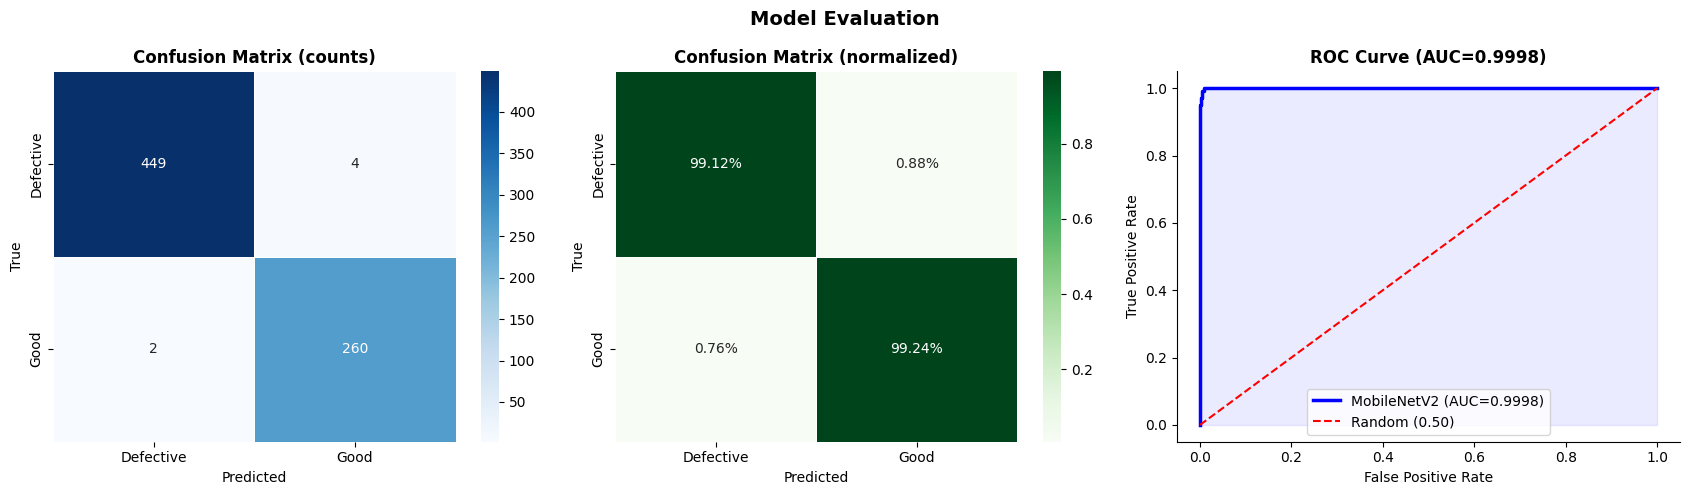

TP (caught defects)    : 260
TN (correct good)      : 449
FP (false alarms)      : 4
FN (missed defects!)   : 2  ← most critical to minimise
✅ Saved: /content/plot_evaluation.png


In [21]:
# ════════════════════════════════════════════════════
# CELL 18 — Confusion Matrix + ROC Curve
# ════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[2].plot(fpr, tpr, 'b-', lw=2.5,
             label=f'MobileNetV2 (AUC={auc_s:.4f})')
axes[2].plot([0,1],[0,1], 'r--', lw=1.5, label='Random (0.50)')
axes[2].fill_between(fpr, tpr, alpha=0.08, color='blue')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title(f'ROC Curve (AUC={auc_s:.4f})', fontweight='bold')
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/plot_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP (caught defects)    : {tp}')
print(f'TN (correct good)      : {tn}')
print(f'FP (false alarms)      : {fp}')
print(f'FN (missed defects!)   : {fn}  ← most critical to minimise')
print('✅ Saved: /content/plot_evaluation.png')

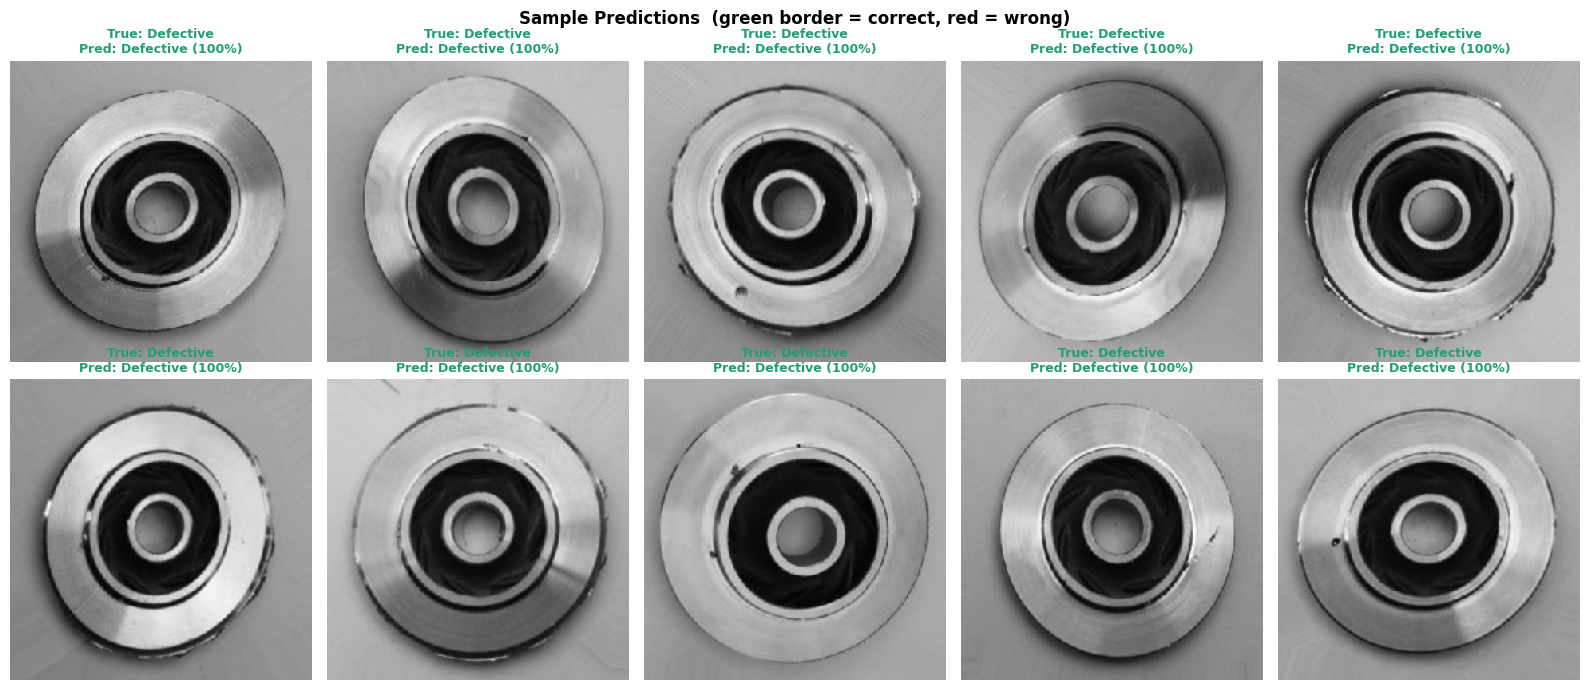

✅ Saved: /content/plot_sample_predictions.png


In [22]:
# ════════════════════════════════════════════════════
# CELL 19 — Sample Predictions Grid
# ════════════════════════════════════════════════════

test_gen.reset()
imgs, lbls = next(test_gen)
probs = best_model.predict(imgs, verbose=0).flatten()
preds = (probs > 0.5).astype(int)

n = min(10, len(imgs))
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Predictions  (green border = correct, red = wrong)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat[:n]):
    ax.imshow(imgs[i])
    ax.axis('off')
    true_l = CLASS_LABELS[int(lbls[i])]
    pred_l = CLASS_LABELS[preds[i]]
    conf   = probs[i] if preds[i] == 1 else 1 - probs[i]
    ok     = (preds[i] == int(lbls[i]))
    color  = '#1D9E75' if ok else '#E24B4A'
    ax.set_title(
        f'True: {true_l}\nPred: {pred_l} ({conf:.0%})',
        fontsize=9, color=color, fontweight='bold'
    )
    for s in ax.spines.values():
        s.set_edgecolor(color); s.set_linewidth(3)

plt.tight_layout()
plt.savefig('/content/plot_sample_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/plot_sample_predictions.png')

---
## 💾 Save & Download

In [25]:
# ════════════════════════════════════════════════════
# CELL 21 — Save model + verify
# ════════════════════════════════════════════════════

# Model is already saved by ModelCheckpoint callback.
# This cell verifies it and prints a final summary.
verify = tf.keras.models.load_model(BEST_MODEL)
loss_v, acc_v = verify.evaluate(test_gen, verbose=0)

print('=' * 55)
print('FINAL MODEL — VERIFIED')
print('=' * 55)
print(f'  Saved at   : {BEST_MODEL}')
print(f'  Test loss  : {loss_v:.4f}')
print(f'  Test acc   : {acc_v*100:.2f}%')
print()
print(f'  Full metrics on test set:')
print(f'    Accuracy  : {acc_s*100:.2f}%')
print(f'    Precision : {prec_s*100:.2f}%')
print(f'    Recall    : {rec_s*100:.2f}%')
print(f'    F1 Score  : {f1_s*100:.2f}%')
print(f'    ROC-AUC   : {auc_s:.4f}')
print('=' * 55)

FINAL MODEL — VERIFIED
  Saved at   : /content/models/casting_defect_model.h5
  Test loss  : 0.0178
  Test acc   : 99.16%

  Full metrics on test set:
    Accuracy  : 99.16%
    Precision : 98.48%
    Recall    : 99.24%
    F1 Score  : 98.86%
    ROC-AUC   : 0.9998


In [26]:
# ════════════════════════════════════════════════════
# CELL 22 — Save to Google Drive  (RECOMMENDED)
#   Keeps your model safe when Colab session ends!
# ════════════════════════════════════════════════════
import shutil
from google.colab import drive

drive.mount('/content/drive')

DRIVE_SAVE = '/content/drive/MyDrive/defect_detection'
os.makedirs(DRIVE_SAVE, exist_ok=True)

# Copy model
shutil.copy(BEST_MODEL, f'{DRIVE_SAVE}/casting_defect_model.h5')

# Copy all plots
plots = [
    '/content/plot_class_distribution.png',
    '/content/plot_sample_images.png',
    '/content/plot_pixel_dist.png',
    '/content/plot_augmentation.png',
    '/content/plot_training_history.png',
    '/content/plot_evaluation.png',
    '/content/plot_sample_predictions.png',
    '/content/plot_gradcam.png',
]
for p in plots:
    if os.path.exists(p):
        shutil.copy(p, f'{DRIVE_SAVE}/{os.path.basename(p)}')

print('✅ Saved to Google Drive:')
for f in sorted(os.listdir(DRIVE_SAVE)):
    kb = os.path.getsize(f'{DRIVE_SAVE}/{f}') / 1024
    print(f'   {f:<45} {kb:7.1f} KB')

Mounted at /content/drive
✅ Saved to Google Drive:
   casting_defect_model.h5                       17669.4 KB
   plot_augmentation.png                           724.3 KB
   plot_class_distribution.png                      57.6 KB
   plot_evaluation.png                             108.0 KB
   plot_pixel_dist.png                              61.6 KB
   plot_sample_images.png                         1188.7 KB
   plot_sample_predictions.png                    1088.7 KB
   plot_training_history.png                       113.7 KB


In [27]:
# ════════════════════════════════════════════════════
# CELL 23 — Download model + plots to your PC
# ════════════════════════════════════════════════════
from google.colab import files

print('Downloading casting_defect_model.h5 ...')
files.download(BEST_MODEL)

for p in plots:
    if os.path.exists(p):
        files.download(p)

print('✅ All files sent to your browser downloads folder!')
print()
print('NEXT STEPS:')
print('  1. Move casting_defect_model.h5 → your project models/ folder')
print('  2. Run: streamlit run app.py')
print('  3. Push to GitHub → deploy on share.streamlit.io')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files sent to your browser downloads folder!

NEXT STEPS:
  1. Move casting_defect_model.h5 → your project models/ folder
  2. Run: streamlit run app.py
  3. Push to GitHub → deploy on share.streamlit.io


Upload any product image to test the model...


Saving WhatsApp Image 2026-03-22 at 12.17.11 PM.jpeg to WhatsApp Image 2026-03-22 at 12.17.11 PM.jpeg


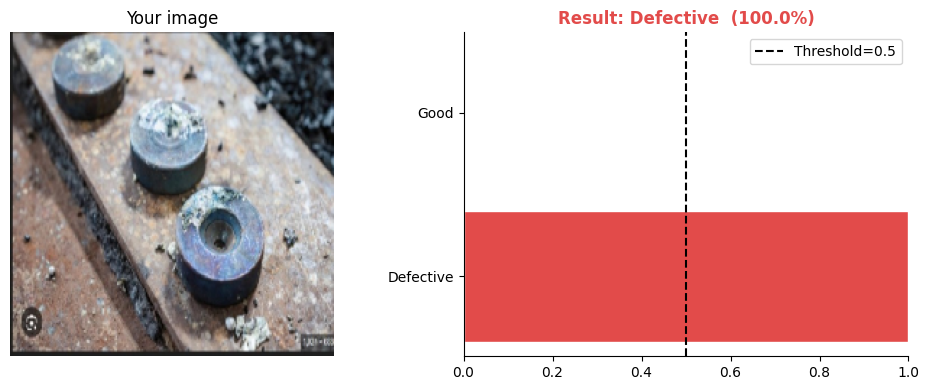


Result     : Defective
Confidence : 100.0%


In [36]:
# ════════════════════════════════════════════════════
# CELL 24 — Test on your own image
# ════════════════════════════════════════════════════
from google.colab import files

def predict_image(img_path, model, threshold=0.5):
    img  = load_img(img_path, target_size=IMG_SIZE)
    arr  = img_to_array(img) / 255.0
    inp  = np.expand_dims(arr, 0)
    prob = float(model.predict(inp, verbose=0)[0][0])
    idx  = 1 if prob > threshold else 0
    conf = prob if idx == 1 else 1 - prob

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(arr); axes[0].axis('off')
    axes[0].set_title('Your image', fontsize=12)

    color = '#1D9E75' if idx == 1 else '#E24B4A'
    axes[1].barh(['Defective', 'Good'], [1-prob, prob],
                 color=['#E24B4A', '#1D9E75'],
                 edgecolor='white')
    axes[1].axvline(threshold, color='black',
                    ls='--', lw=1.5,
                    label=f'Threshold={threshold}')
    axes[1].set_xlim(0, 1)
    axes[1].set_title(
        f'Result: {CLASS_LABELS[idx]}  ({conf:.1%})',
        color=color, fontsize=12, fontweight='bold'
    )
    axes[1].legend()
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()

    return CLASS_LABELS[idx], conf

print('Upload any product image to test the model...')
uploaded = files.upload()

for fname in uploaded.keys():
    save_path = f'/content/{fname}'
    with open(save_path, 'wb') as f:
        f.write(uploaded[fname])
    label, confidence = predict_image(save_path, best_model)
    print(f'\nResult     : {label}')
    print(f'Confidence : {confidence:.1%}')